# Exercises 1
## 1.1

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.stats import chi2, chisquare, kstest
import math as math

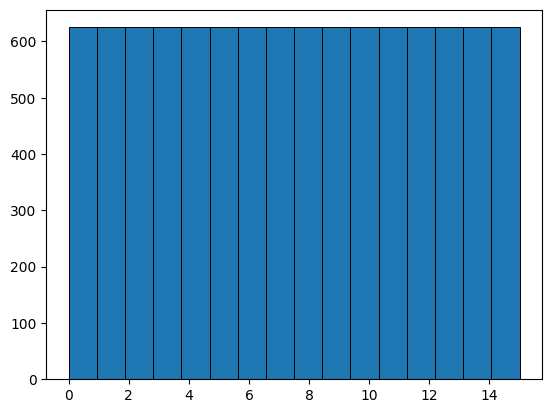

In [2]:
def lcg(n: int, a: int, c: int, x0:int = 42, M: int = 12):
    out = [x0]
    for _ in range(n-1):
        xi=(a*out[-1]+c)%M
        out.append(xi)
    return out

out = lcg(10000, 5, 1, 3, 16)

plt.hist(out, bins=16, edgecolor='black', linewidth=0.7)
plt.show()

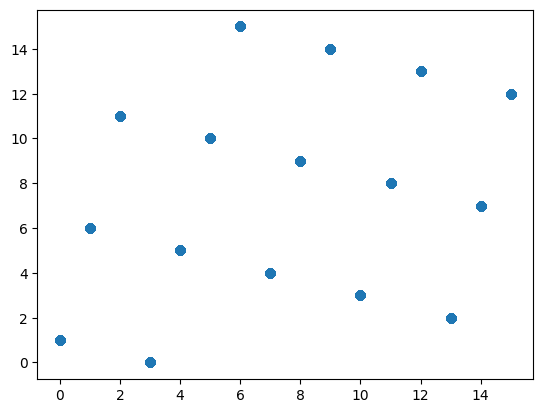

In [3]:
plt.scatter(out[:-1],out[1:])
plt.show()

In [4]:
def chi2Test(observed: list[int], bins: int, alpha: float = 0.05):
    expected = len(observed) / bins
    counts = pd.Series(observed).value_counts().reindex(range(bins), fill_value=0)
    chi_stat = ((counts - expected)**2 / expected).sum()

    df = bins - 1
    
    p_val = 1-chi2.cdf(chi_stat,df=df)
    crit_val = chi2.ppf(1-alpha,df=df)
    reject = chi_stat > crit_val
    print(f"Chi2 statistic:  {chi_stat:.4f}")
    print(f"Critical value:  {crit_val:.4f}  (alpha={alpha}, df={df})")
    print(f"p-value:         {p_val:.4f}")
    print(f"Reject H0:       {reject}")
    return chi_stat, p_val, reject
    
chi2Test(out,10)

Chi2 statistic:  1406.2500
Critical value:  16.9190  (alpha=0.05, df=9)
p-value:         0.0000
Reject H0:       True


(np.float64(1406.25), np.float64(0.0), np.True_)

In [5]:
def ks_test(observed: list[int], M: int, alpha: float = 0.05):
    n = len(observed)
    u = sorted(x / M for x in observed)

    d_plus  = max((i + 1) / n - u[i] for i in range(n))
    d_minus = max(u[i] - i / n       for i in range(n))
    D = max(d_plus, d_minus)

    c = {0.15: 1.138,0.10: 1.224, 0.05: 1.358, 0.01: 1.628}
    crit_val = c.get(alpha, 1.358)
    
    adjusted = (math.sqrt(n) + 0.12 + 0.11 / math.sqrt(n))*D
    
    reject = adjusted > crit_val

    print(f"KS statistic:    {D:.6f}")
    print(f"Adjusted stat:   {adjusted:.4f}")
    print(f"Critical value:  {crit_val:.4f}  (alpha={alpha})")
    print(f"Reject H0:       {reject}")
    return D, reject

ks_test(out, 16)

KS statistic:    0.062500
Adjusted stat:   6.2576
Critical value:  1.3580  (alpha=0.05)
Reject H0:       True


(0.0625, True)

In [6]:
def run_test1(observed: list[int], alpha: float = 0.05):
    median = sorted(observed)[len(observed) // 2]

    # Label each value as +1 (above) or -1 (below), skip ties
    signs = [1 if x > median else -1 for x in observed if x != median]

    n1 = signs.count(1)   # above
    n2 = signs.count(-1)  # below
    n  = n1 + n2

    # Count runs
    runs = []
    length = 1
    for i in range(1, len(signs)):
        if signs[i] == signs[i - 1]:
            length += 1
        else:
            runs.append(length)
            length = 1
    runs.append(length)
    R = len(runs)

    mu    = (2 * n1 * n2) / n + 1
    var = math.sqrt((2 * n1 * n2 * (2 * n1 * n2 - n)) / (n**2 * (n - 1)))
    Z = (R - mu) / var

    p_value = math.erfc(abs(Z) / math.sqrt(2))

    z_crit = {0.10: 1.645, 0.05: 1.960, 0.01: 2.576}
    crit_val = z_crit.get(alpha, 1.960)

    reject = abs(Z) > crit_val
    print(f"Median:             {median}")
    print(f"n1 (above):         {n1},        n2 (below): {n2}")
    print(f"Runs:               {R}")
    print(f"Avg run length:     {sum(runs)/R:.4f}")
    print(f"Max run length:     {max(runs)}")
    print(f"Expected runs:      {mu:.2f}  (std={var:.2f})")
    print(f"Z statistic:        {Z:.4f}")
    print(f"Critical value +-:  {crit_val}  (alpha={alpha})")
    print(f"p-value:            {p_value:.4f}")
    print(f"Reject H0:          {reject}")
    return R, Z, p_value, reject#, runs

run_test1(out)

Median:             8
n1 (above):         4375,        n2 (below): 5000
Runs:               3750
Avg run length:     2.5000
Max run length:     4
Expected runs:      4667.67  (std=48.19)
Z statistic:        -19.0409
Critical value +-:  1.96  (alpha=0.05)
p-value:            0.0000
Reject H0:          True


(3750, -19.040887489585764, 7.819142629462032e-81, True)

In [7]:
def run_test2(observed: list[int], alpha: float = 0.05):
    n = len(observed)

    signs = []
    for i in range(1, n):
        if observed[i] > observed[i - 1]:
            signs.append(1)
        elif observed[i] < observed[i - 1]:
            signs.append(-1)

    runs = []
    length = 1
    for i in range(1, len(signs)):
        if signs[i] == signs[i - 1]:
            length += 1
        else:
            runs.append(length)
            length = 1
    runs.append(length)

    R = len(runs)

    # Knuth's formulas â€” n is the original sequence length
    mu    = (2 * n - 1) / 3
    sigma = math.sqrt((16 * n - 29) / 90)
    Z     = (R - mu) / sigma

    p_value  = math.erfc(abs(Z) / math.sqrt(2))
    z_crit   = {0.10: 1.645, 0.05: 1.960, 0.01: 2.576}
    crit_val = z_crit.get(alpha, 1.960)

    # Run length distribution (Knuth groups length >= 6)
    length_counts = {k: 0 for k in range(1, 7)}
    for l in runs:
        length_counts[min(l, 6)] += 1

    reject = abs(Z) > crit_val
    print(f"n:               {n}")
    print(f"Runs (R):        {R}")
    print(f"Run length dist: { {k: length_counts[k] for k in range(1, 7)} }")
    print(f"Avg run length:  {sum(runs)/R:.4f}")
    print(f"Max run length:  {max(runs)}")
    print(f"Expected runs:   {mu:.2f}  (std={sigma:.2f})")
    print(f"Z statistic:     {Z:.4f}")
    print(f"Critical value:  {crit_val}  (alpha={alpha})")
    print(f"p-value:         {p_value:.4f}")
    print(f"Reject H0:       {reject}")
    return R, Z, p_value, reject

run_test2([0.54, 0.67, 0.13, 0.89, 0.33, 0.45, 0.90, 0.01, 0.45, 0.76, 0.82, 0.24, 0.17])


n:               13
Runs (R):        8
Run length dist: {1: 5, 2: 2, 3: 1, 4: 0, 5: 0, 6: 0}
Avg run length:  1.5000
Max run length:  3
Expected runs:   8.33  (std=1.41)
Z statistic:     -0.2364
Critical value:  1.96  (alpha=0.05)
p-value:         0.8132
Reject H0:       False


(8, -0.23635972962353313, 0.8131535420563127, False)

In [ ]:
def run_test3(observed: list, alpha: float = 0.05):
    n = len(observed)

    # Sign sequence, skip ties
    signs = []
    for i in range(1, n):
        if observed[i] > observed[i - 1]:
            signs.append(1)
        elif observed[i] < observed[i - 1]:
            signs.append(-1)

    # Collect run lengths
    runs = []
    length = 1
    for i in range(1, len(signs)):
        if signs[i] == signs[i - 1]:
            length += 1
        else:
            runs.append(length)
            length = 1
    runs.append(length)

    # R vector: counts of runs of length 1,2,3,4,5,>=6
    R = [0] * 6
    for l in runs:
        R[min(l, 6) - 1] += 1

    # B[k] = (kÂ²+k-1) / (k+2)!  for k=1..5;  B[5] = 0.5 - sum(B[0:5])
    B = [(k**2 + k - 1) / math.factorial(k + 2) for k in range(1, 6)]
    B.append(0.5 - sum(B))

    A = [
        [4529.4, 9044.9, 13568,  18091,  22615,  27892 ],
        [9044.9, 18097,  27139,  36187,  45234,  55789 ],
        [13568,  27139,  40721,  54281,  67852,  83685 ],
        [18091,  36187,  54281,  72414,  90470,  111580],
        [22615,  45234,  67852,  90470,  113262, 139476],
        [27892,  55789,  83685,  111580, 139476, 172860],
    ]

    # d = R - n*B
    d = [R[i] - n * B[i] for i in range(6)]

    # Ad = A @ d
    Ad = [sum(A[i][j] * d[j] for j in range(6)) for i in range(6)]

    # Z = (1/(n-6)) * d^T * Ad
    Z = sum(d[i] * Ad[i] for i in range(6)) / (n - 6)

    p_value  = 1 - chi2.cdf(Z, df=6)
    crit_val = chi2.ppf(1 - alpha, df=6)

    reject = Z > crit_val
    print(f"R (run length counts): {dict(zip(range(1,7), R))}")
    print(f"E[R] = n*B:            {[round(n*b, 2) for b in B]}")
    print(f"Z statistic:           {Z:.4f}")
    print(f"Critical value:        {crit_val:.4f}  (chi2(6), alpha={alpha})")
    print(f"p-value:               {p_value:.4f}")
    print(f"Reject H0:             {reject}")
    return Z, p_value, reject

run_test3(out)


R (run length counts): {1: 3126, 2: 2499, 3: 625, 4: 0, 5: 0, 6: 0}
E[R] = n*B:            [1666.67, 2083.33, 916.67, 263.89, 57.54, 11.9]
Z statistic:           2025.9079
Critical value:        12.5916  (chi2(6), alpha=0.05)
p-value:               0.0000
Reject H0:             True


(2025.9078889107095, np.float64(0.0), np.True_)

In [ ]:
def chi2_uniform(u, k=10, alpha=0.05):
    n = len(u)
    counts, _ = np.histogram(u, bins=np.linspace(0, 1, k + 1))
    expected  = n / k
    stat = float(sum((o - expected)**2 / expected for o in counts))
    df   = k - 1
    p    = float(1 - chi2.cdf(stat, df))
    crit = float(chi2.ppf(1 - alpha, df))
    rej  = stat > crit
    print(f"Chi2 statistic:  {stat:.4f}")
    print(f"Critical value:  {crit:.4f}  (alpha={alpha}, df={df})")
    print(f"p-value:         {p:.4f}")
    print(f"Reject H0:       {rej}")
    return stat, p, rej


def ks_uniform(u, alpha=0.05):
    """KS test vs Uniform(0,1), all parameters known (case 1 from slides)."""
    n   = len(u)
    u_s = sorted(u)
    d_p = max((i + 1) / n - u_s[i] for i in range(n))
    d_m = max(u_s[i] - i / n       for i in range(n))
    D   = max(d_p, d_m)
    c   = {0.15: 1.138, 0.10: 1.224, 0.05: 1.358, 0.025: 1.480, 0.01: 1.628}
    adj  = (math.sqrt(n) + 0.12 + 0.11 / math.sqrt(n)) * D
    crit = c.get(alpha, 1.358)
    rej  = adj > crit
    print(f"KS statistic:    {D:.6f}")
    print(f"Adjusted stat:   {adj:.4f}")
    print(f"Critical value:  {crit:.4f}  (alpha={alpha})")
    print(f"Reject H0:       {rej}")
    return D, rej


def correlation_test(u, h_max=20, alpha=0.05):
    """Serial independence via h-lag cross-moments (slide 33). u: list in [0,1)."""
    n      = len(u)
    mu_0   = 1 / 4
    sigma  = math.sqrt(7 / (144 * n))
    z_crit = {0.10: 1.645, 0.05: 1.960, 0.01: 2.576}.get(alpha, 1.960)
    print(f"{'h':>4} {'C_h':>10} {'Z':>8} {'p-value':>10} {'Reject H0':>12}")
    print("-" * 50)
    n_rej = 0
    for h in range(1, h_max + 1):
        C_h = sum(u[i] * u[i + h] for i in range(n - h)) / (n - h)
        Z   = (C_h - mu_0) / sigma
        p   = math.erfc(abs(Z) / math.sqrt(2))
        rej = abs(Z) > z_crit
        n_rej += rej
        print(f"{h:>4} {C_h:>10.6f} {Z:>8.4f} {p:>10.4f} {'Yes' if rej else 'No':>12}")
    print(f"\nRejected {n_rej}/{h_max} lags at alpha={alpha}")


def run_all_tests(u, label='', k=10, h_max=20, alpha=0.05):
    """Run all 5 tests on a [0,1) sequence."""
    print('=' * 60)
    print(f'Testing: {label}  (n={len(u)})')
    print('=' * 60)
    print('\n--- Chi-square test ---')
    chi2_uniform(u, k=k, alpha=alpha)
    print('\n--- KS test ---')
    ks_uniform(u, alpha=alpha)
    print('\n--- Wald-Wolfowitz run test (above/below median) ---')
    run_test1(u, alpha=alpha)
    print('\n--- Up/down run test ---')
    run_test2(u, alpha=alpha)
    print('\n--- Knuth run-length test ---')
    run_test3(u, alpha=alpha)
    print('\n--- Correlation test (lags 1-20) ---')
    correlation_test(u, h_max=h_max, alpha=alpha)


In [10]:
# Apply correlation test to the initial (bad) LCG
out_norm = [x / 16 for x in out]
print('=== Correlation test — initial LCG (a=5, c=1, M=16) ===')
correlation_test(out_norm)


=== Correlation test — initial LCG (a=5, c=1, M=16) ===
   h        C_h        Z    p-value    Reject H0
--------------------------------------------------
   1   0.242200  -3.5377     0.0004          Yes
   2   0.216834 -15.0425     0.0000          Yes
   3   0.195363 -24.7812     0.0000          Yes
   4   0.209034 -18.5803     0.0000          Yes
   5   0.226588 -10.6189     0.0000          Yes
   6   0.216828 -15.0453     0.0000          Yes
   7   0.210956 -17.7086     0.0000          Yes
   8   0.177734 -32.7766     0.0000          Yes
   9   0.210919 -17.7256     0.0000          Yes
  10   0.216766 -15.0737     0.0000          Yes
  11   0.226537 -10.6416     0.0000          Yes
  12   0.208934 -18.6256     0.0000          Yes
  13   0.195262 -24.8266     0.0000          Yes
  14   0.216759 -15.0766     0.0000          Yes
  15   0.242175  -3.5491     0.0004          Yes
  16   0.302734  23.9181     0.0000          Yes
  17   0.242200  -3.5377     0.0004          Yes
  18   0.21

## Part 1.3

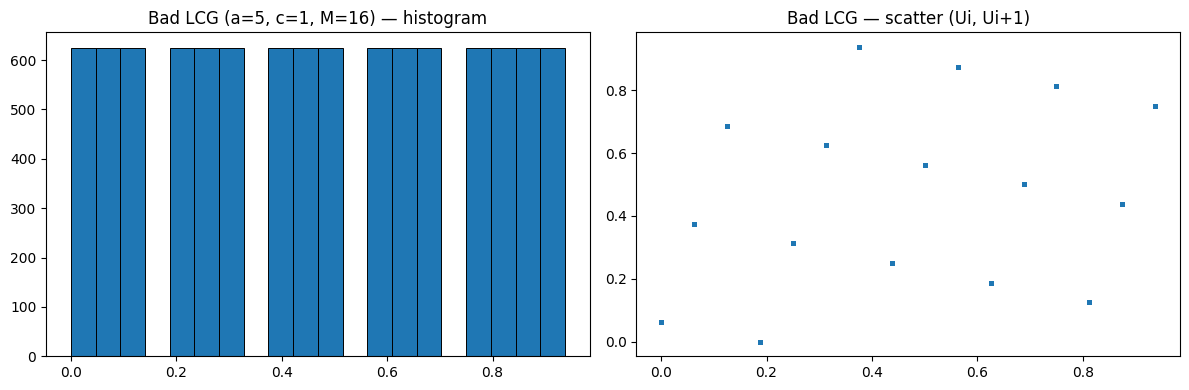

Testing: Bad LCG: a=5, c=1, M=16  (n=10000)

--- Chi-square test ---
Chi2 statistic:  937.5000
Critical value:  16.9190  (alpha=0.05, df=9)
p-value:         0.0000
Reject H0:       True

--- KS test ---
KS statistic:    0.062500
Adjusted stat:   6.2576
Critical value:  1.3580  (alpha=0.05)
Reject H0:       True

--- Wald-Wolfowitz run test (above/below median) ---
Median:             0.5
n1 (above):         4375,        n2 (below): 5000
Runs:               3750
Avg run length:     2.5000
Max run length:     4
Expected runs:      4667.67  (std=48.19)
Z statistic:        -19.0409
Critical value +-:  1.96  (alpha=0.05)
p-value:            0.0000
Reject H0:          True

--- Up/down run test ---
n:               10000
Runs (R):        6250
Run length dist: {1: 3126, 2: 2499, 3: 625, 4: 0, 5: 0, 6: 0}
Avg run length:  1.5998
Max run length:  3
Expected runs:   6666.33  (std=42.16)
Z statistic:     -9.8751
Critical value:  1.96  (alpha=0.05)
p-value:         0.0000
Reject H0:       True

--

In [11]:
# Bad LCG (a=5, c=1, M=16) — visual + all 5 tests
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(out_norm, bins=20, edgecolor='black', linewidth=0.7)
axes[0].set_title('Bad LCG (a=5, c=1, M=16) — histogram')
axes[1].scatter(out_norm[:-1], out_norm[1:], s=5, alpha=0.5)
axes[1].set_title('Bad LCG — scatter (Ui, Ui+1)')
plt.tight_layout(); plt.show()

run_all_tests(out_norm, label='Bad LCG: a=5, c=1, M=16')


### Final Choice

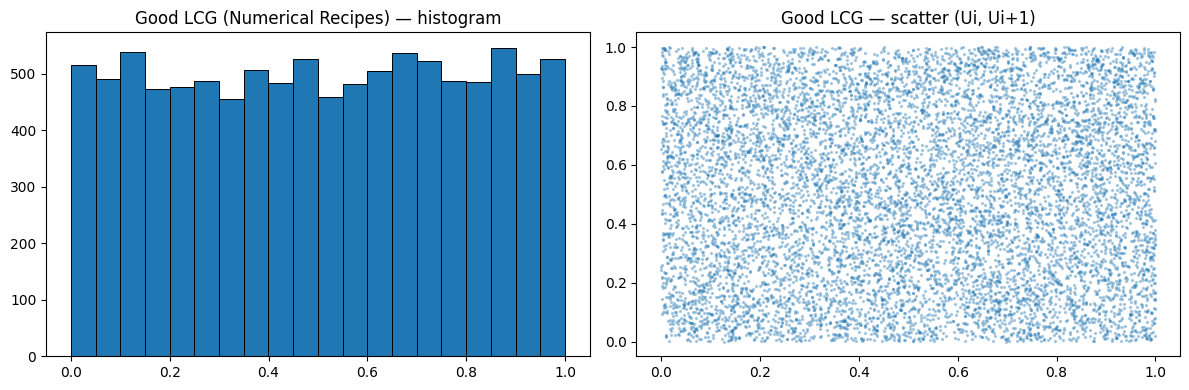

Testing: Good LCG: a=1664525, c=1013904223, M=2^32  (n=10000)

--- Chi-square test ---
Chi2 statistic:  9.7100
Critical value:  16.9190  (alpha=0.05, df=9)
p-value:         0.3745
Reject H0:       False

--- KS test ---
KS statistic:    0.012406
Adjusted stat:   1.2421
Critical value:  1.3580  (alpha=0.05)
Reject H0:       False

--- Wald-Wolfowitz run test (above/below median) ---
Median:             0.5046728095039725
n1 (above):         4999,        n2 (below): 5000
Runs:               4974
Avg run length:     2.0103
Max run length:     13
Expected runs:      5000.50  (std=49.99)
Z statistic:        -0.5301
Critical value +-:  1.96  (alpha=0.05)
p-value:            0.5961
Reject H0:          False

--- Up/down run test ---
n:               10000
Runs (R):        6645
Run length dist: {1: 4159, 2: 1807, 3: 524, 4: 124, 5: 28, 6: 3}
Avg run length:  1.5047
Max run length:  6
Expected runs:   6666.33  (std=42.16)
Z statistic:     -0.5060
Critical value:  1.96  (alpha=0.05)
p-value:    

In [12]:
# Good LCG (Numerical Recipes)
M_nr         = 2**32
out_good_raw = lcg(10000, a=1664525, c=1013904223, x0=42, M=M_nr)
out_good     = [x / M_nr for x in out_good_raw]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(out_good, bins=20, edgecolor='black', linewidth=0.7)
axes[0].set_title('Good LCG (Numerical Recipes) — histogram')
axes[1].scatter(out_good[:-1], out_good[1:], s=2, alpha=0.3)
axes[1].set_title('Good LCG — scatter (Ui, Ui+1)')
plt.tight_layout(); plt.show()

run_all_tests(out_good, label='Good LCG: a=1664525, c=1013904223, M=2^32')


## Part 2

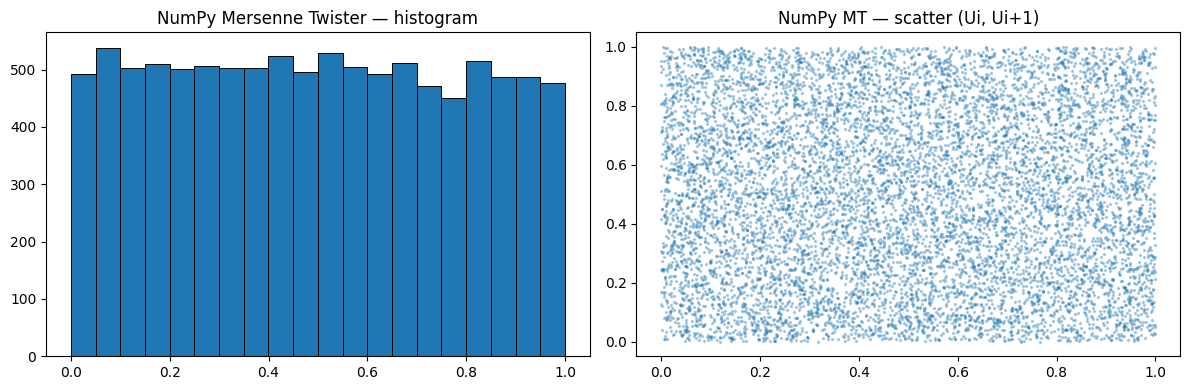

Testing: NumPy Mersenne Twister  (n=10000)

--- Chi-square test ---
Chi2 statistic:  9.7500
Critical value:  16.9190  (alpha=0.05, df=9)
p-value:         0.3711
Reject H0:       False

--- KS test ---
KS statistic:    0.012529
Adjusted stat:   1.2544
Critical value:  1.3580  (alpha=0.05)
Reject H0:       False

--- Wald-Wolfowitz run test (above/below median) ---
Median:             0.49253538071428926
n1 (above):         4999,        n2 (below): 5000
Runs:               5061
Avg run length:     1.9757
Max run length:     12
Expected runs:      5000.50  (std=49.99)
Z statistic:        1.2101
Critical value +-:  1.96  (alpha=0.05)
p-value:            0.2262
Reject H0:          False

--- Up/down run test ---
n:               10000
Runs (R):        6672
Run length dist: {1: 4197, 2: 1796, 3: 537, 4: 113, 5: 27, 6: 2}
Avg run length:  1.4987
Max run length:  6
Expected runs:   6666.33  (std=42.16)
Z statistic:     0.1344
Critical value:  1.96  (alpha=0.05)
p-value:         0.8931
Reject H

In [13]:
# NumPy Mersenne Twister
np.random.seed(42)
u_sys = list(np.random.uniform(0, 1, 10000))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(u_sys, bins=20, edgecolor='black', linewidth=0.7)
axes[0].set_title('NumPy Mersenne Twister — histogram')
axes[1].scatter(u_sys[:-1], u_sys[1:], s=2, alpha=0.3)
axes[1].set_title('NumPy MT — scatter (Ui, Ui+1)')
plt.tight_layout(); plt.show()

run_all_tests(u_sys, label='NumPy Mersenne Twister')


## Part 3

Running 200 seeds per generator...
Done.


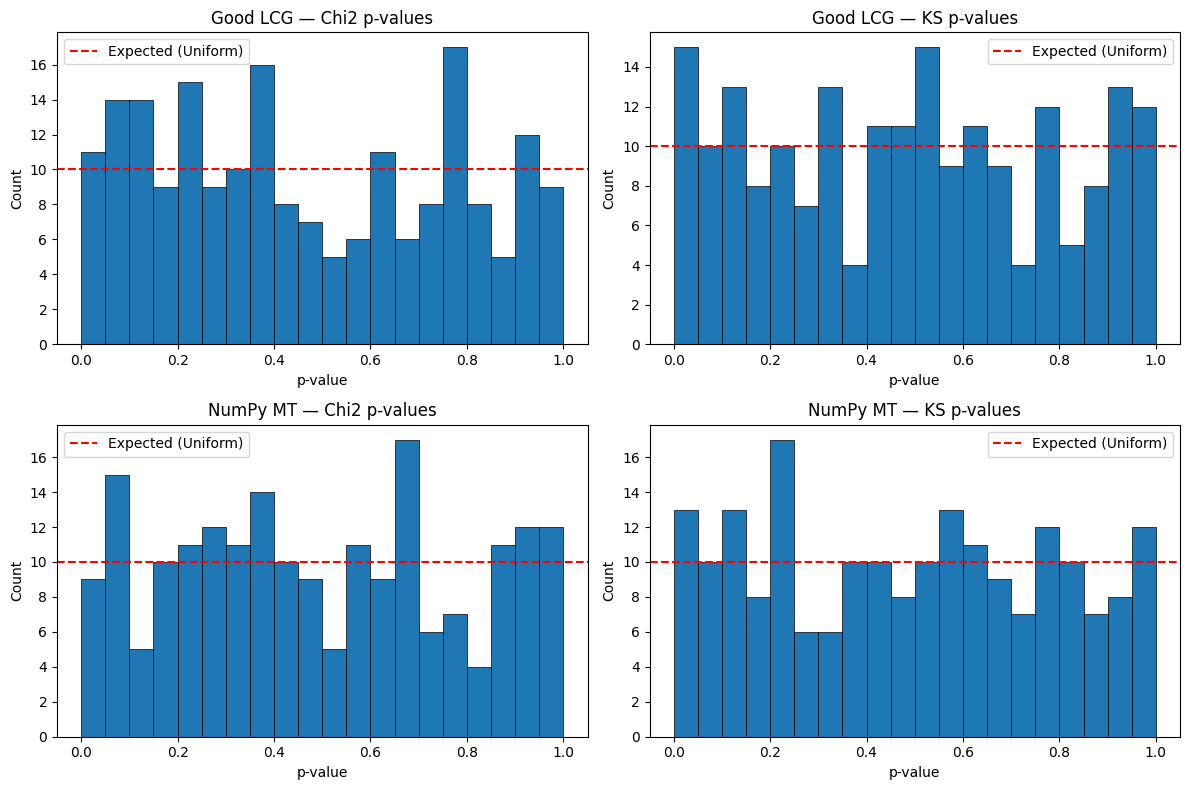


Generator          Test      Rejection rate  (expect ~0.05)
------------------------------------------------
Good LCG           Chi2               0.055
                   KS                 0.075
NumPy MT           Chi2               0.045
                   KS                 0.065


In [14]:
# Part 3: p-value distributions over 200 seeds
N_SEEDS = 200
N       = 10_000
alpha   = 0.05

def collect_pvals(gen_fn, n_seeds=N_SEEDS, n=N):
    p_c, p_k = [], []
    for seed in range(n_seeds):
        u = gen_fn(seed)
        counts, _ = np.histogram(u, bins=np.linspace(0, 1, 11))
        _, pc = chisquare(counts)
        _, pk = kstest(u, 'uniform')
        p_c.append(float(pc))
        p_k.append(float(pk))
    return np.array(p_c), np.array(p_k)

def good_lcg_fn(seed):
    return [x / M_nr for x in lcg(N, 1664525, 1013904223, seed, M_nr)]

def numpy_fn(seed):
    np.random.seed(seed)
    return np.random.uniform(0, 1, N)

print(f'Running {N_SEEDS} seeds per generator...')
p_c_lcg, p_k_lcg = collect_pvals(good_lcg_fn)
p_c_sys, p_k_sys = collect_pvals(numpy_fn)
print('Done.')

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, pv, title in zip(
    axes.flat,
    [p_c_lcg, p_k_lcg, p_c_sys, p_k_sys],
    ['Good LCG — Chi2 p-values', 'Good LCG — KS p-values',
     'NumPy MT — Chi2 p-values',  'NumPy MT — KS p-values']
):
    ax.hist(pv, bins=20, range=(0, 1), edgecolor='black', linewidth=0.5)
    ax.axhline(N_SEEDS / 20, color='r', linestyle='--', label='Expected (Uniform)')
    ax.set_title(title)
    ax.set_xlabel('p-value')
    ax.set_ylabel('Count')
    ax.legend()
plt.tight_layout()
plt.show()

print(f"\n{'Generator':<18} {'Test':<8} {'Rejection rate':>15}  (expect ~{alpha:.2f})")
print('-' * 48)
for name, pc, pk in [('Good LCG', p_c_lcg, p_k_lcg), ('NumPy MT', p_c_sys, p_k_sys)]:
    print(f"{name:<18} {'Chi2':<8} {np.mean(pc < alpha):>15.3f}")
    print(f"{'': <18} {'KS':<8} {np.mean(pk < alpha):>15.3f}")
